# Shopper-Pulse

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('../data/customers_data.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [8]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

### Data-Preprocessing

##### 1. Handling Missing Values

In [9]:
df['Income'] = df['Income'].fillna(df['Income'].median())

##### 2. Feature Engineering

In [10]:
# Convert year-of-birth to age
from datetime import date
current_year = date.today().year

current_year

df['Age'] = current_year - df['Year_Birth']

In [11]:
# Convert Dt-Customer to Customer Joining Date
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

reference_date = df['Dt_Customer'].max()

df['Customer_Tenure_Period'] = (reference_date - df['Dt_Customer']).dt.days

In [12]:
# Spending & Kids (Accumulation)
df['Total_Spending'] = df[['MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds']].sum(axis=1)

df['Total_Children'] = df[['Kidhome', 'Teenhome']].sum(axis=1)

df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Period,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,9,3,4,5,0,0,59,381,1341,1
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,8,2,5,7,0,0,80,19,444,3
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,2,3,13,6,0,0,45,155,1241,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,6,5,10,3,0,0,70,156,843,1


In [13]:
df['Total_Children'].value_counts()

Total_Children
1    1128
0     638
2     421
3      53
Name: count, dtype: int64

In [14]:
df['Education'].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [15]:
# Education

df['Education'].value_counts()
# Categories -> UG, Grad, PG

df['Education'] = df['Education'].replace(['Basic', '2n Cycle'], 'Undergraduate')
df['Education'] = df['Education'].replace('Graduation', 'Graduate')
df['Education'] = df['Education'].replace(['Master', 'PhD'], 'Postgraduate')

In [16]:
# Marital Status

df['Living_With'] = df['Marital_Status'].replace({
    'Married': 'Partner', 'Together': 'Partner',
    'Single': 'Alone', 'Divorced': 'Alone', 'Widow': 'Alone', 'Alone': 'Alone', 'Absurd': 'Alone', 'YOLO': 'Alone'
})

##### 3. Dropping Columns

In [17]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Period',
       'Total_Spending', 'Total_Children', 'Living_With'],
      dtype='str')

In [18]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

##### 4. Handle Outliers

In [19]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Period,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


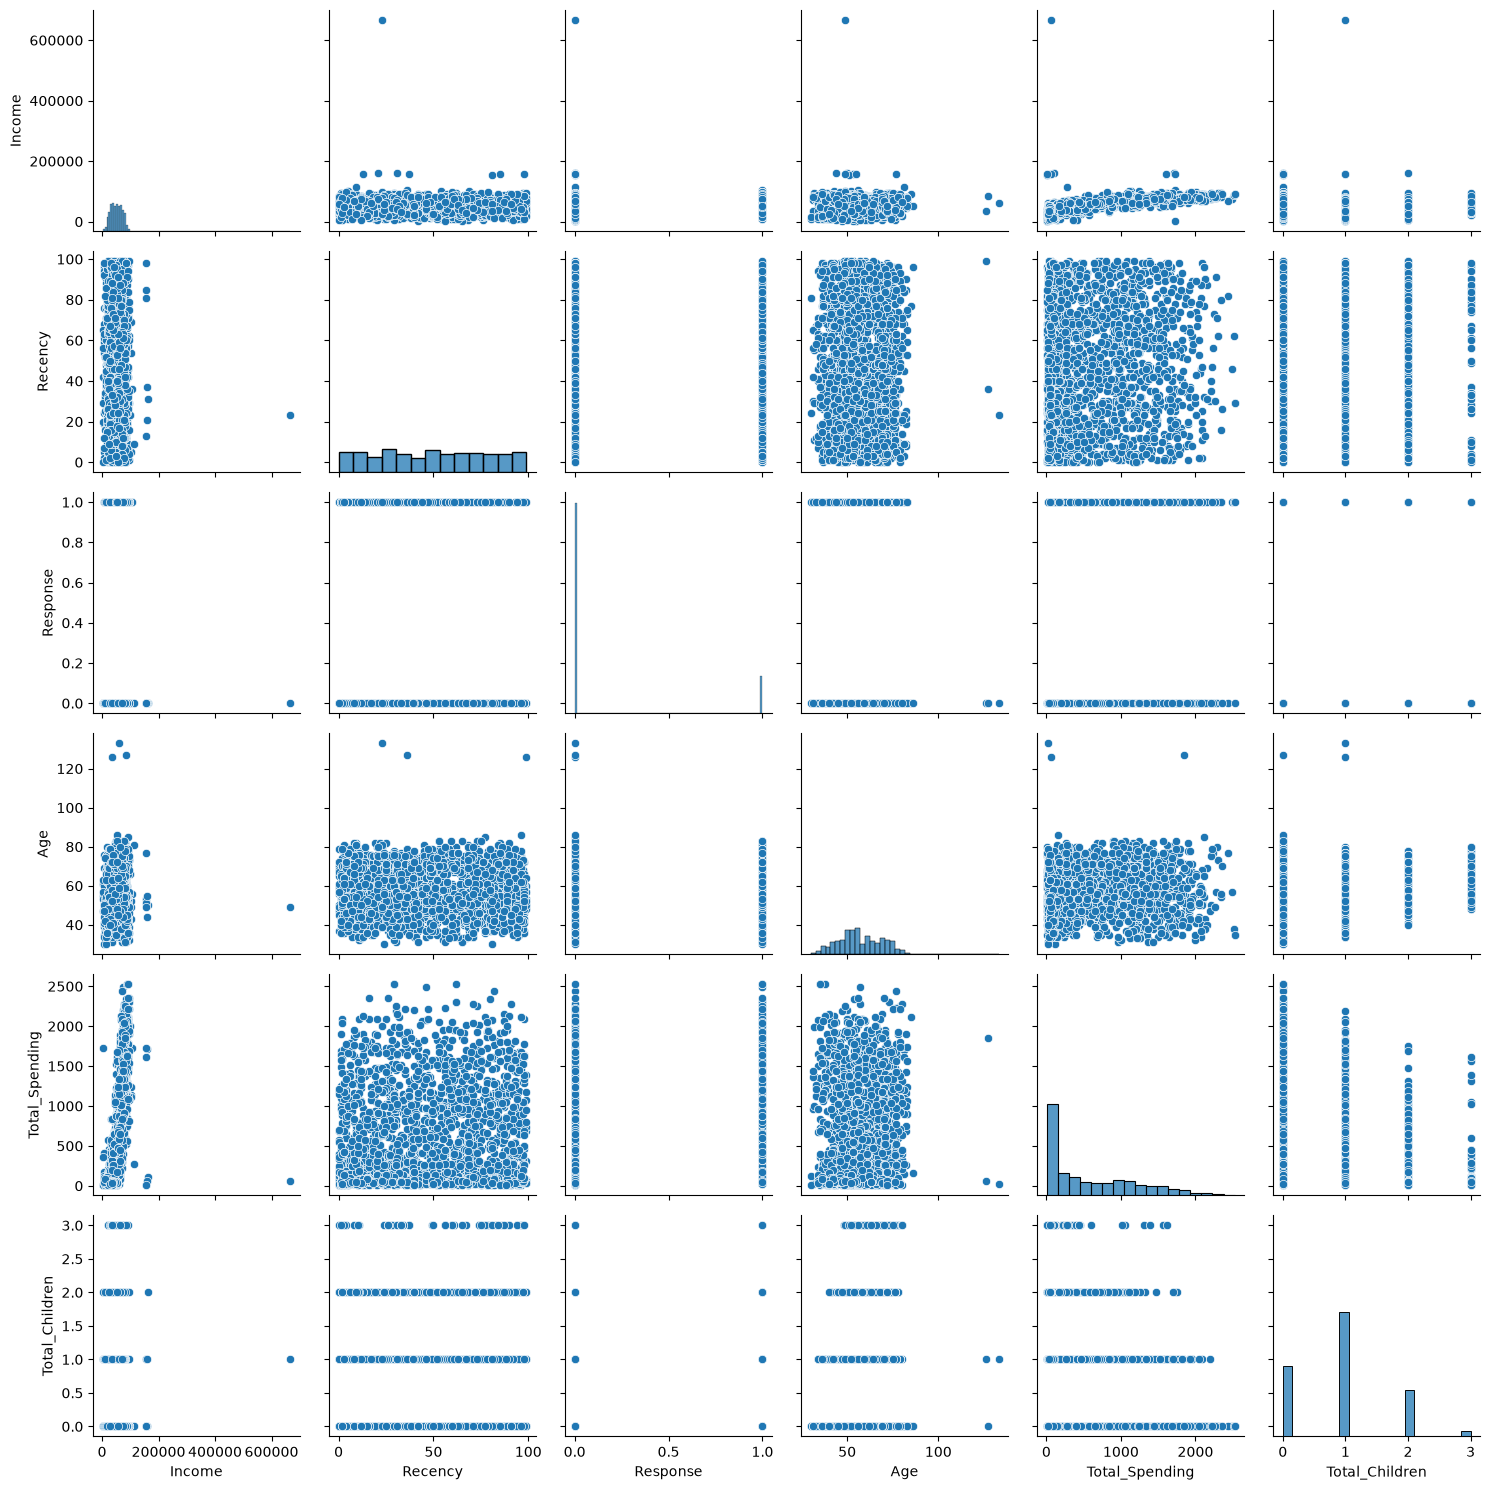

In [20]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

# Pair-Plots
sns.pairplot(df_cleaned[cols])
plt.tight_layout()

In [21]:
# Remove Outliers

print("Data size with outliers:", len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned['Age'] < 90) ]
df_cleaned = df_cleaned[ (df_cleaned['Income'] < 150_000) ]

print("Data size without outliers:", len(df_cleaned))

Data size with outliers: 2240
Data size without outliers: 2229


##### 5. Correlation Heatmap

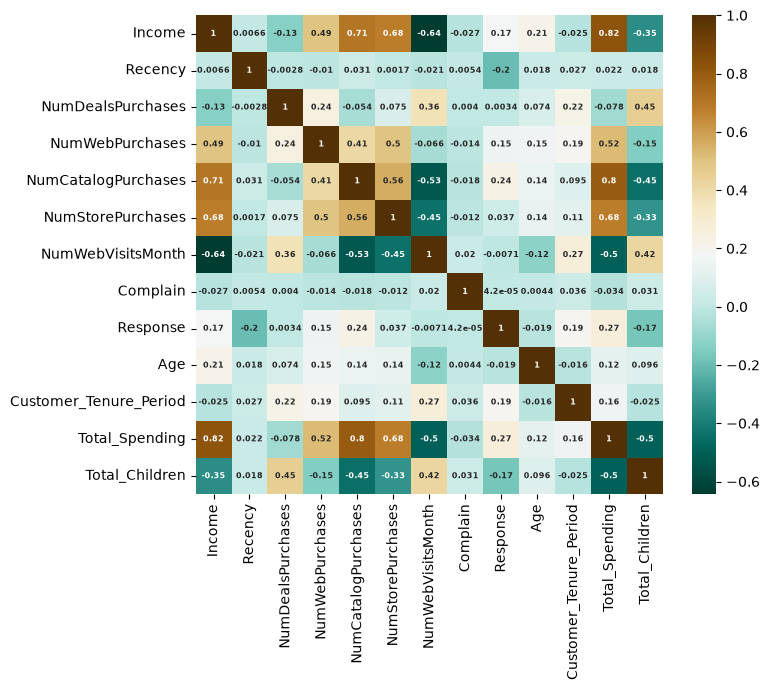

In [22]:
corr_matrix = df_cleaned.corr(numeric_only=True)

plt.figure(figsize=(8,7))
sns.heatmap(corr_matrix, annot=True, cmap='BrBG_r', annot_kws={'size': 6, 'weight': 'bold'})
plt.tight_layout()
plt.show()

##### 6. Feature Encoding

In [23]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()

cat_cols = ['Education', 'Living_With']
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(), index=df_cleaned.index)

df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols), enc_df], axis=1)


In [24]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Period,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


##### 7. Scaling

In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_encoded)

##### 8. Visualize

In [26]:
X_scaled.shape

(2229, 18)

Ratio: [0.23720749 0.1137673 ]


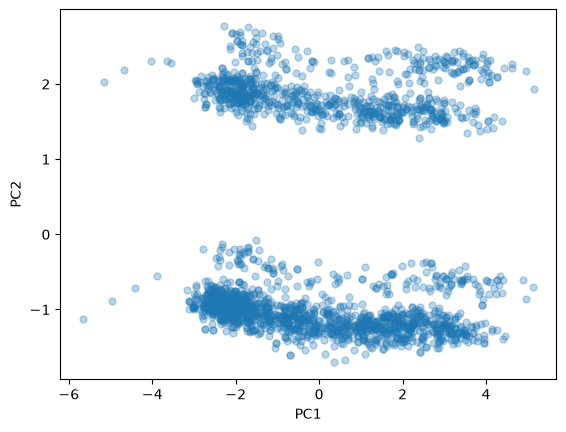

In [27]:
# PCA in 2D
from sklearn.decomposition import PCA

pca = PCA(2)

X_pca_2d = pca.fit_transform(X_scaled)

# Plot
plt.scatter(x=X_pca_2d[:,0], y=X_pca_2d[:,1], s=25, alpha=0.3)
plt.xlabel("PC1")
plt.ylabel("PC2")

print('Ratio:', pca.explained_variance_ratio_)

Ratio: [0.23720749 0.1137673  0.10436899]


Text(0.5, 0, 'PC3')

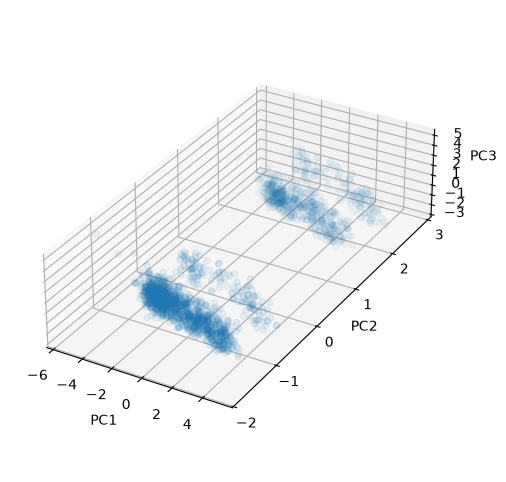

In [28]:
# PCA in 3D
pca = PCA(3)

X_pca = pca.fit_transform(X_scaled)

print('Ratio:', pca.explained_variance_ratio_)

# Plot
fig = plt.figure(figsize=(20,6), dpi=100)
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], alpha=0.3)
ax.set_box_aspect((2, 4, 1))
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

### Analyze K value

##### 1. Elbow Method

Text(0, 0.5, 'WCSS')

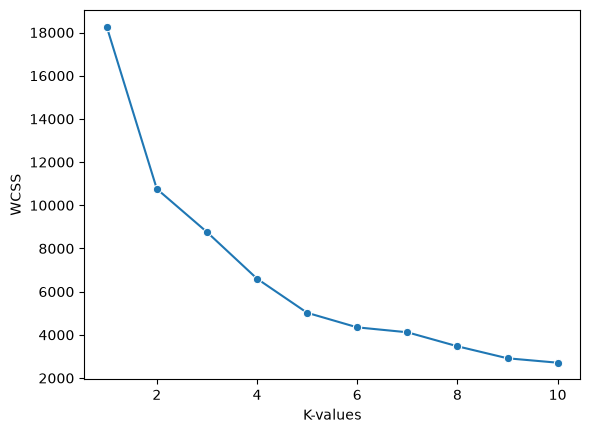

In [29]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1,11):
    kmeans = KMeans(k, random_state=42)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

sns.lineplot(x=range(1,11), y=wcss, marker='o')
plt.xlabel("K-values")
plt.ylabel("WCSS")

In [30]:
kneedle = KneeLocator(range(1,11), wcss, curve='convex', direction='decreasing')
optimal_k = kneedle.knee

In [31]:
print(optimal_k)

4


##### 2. Silhouette Score

Text(0, 0.5, 'Silhouette Scores')

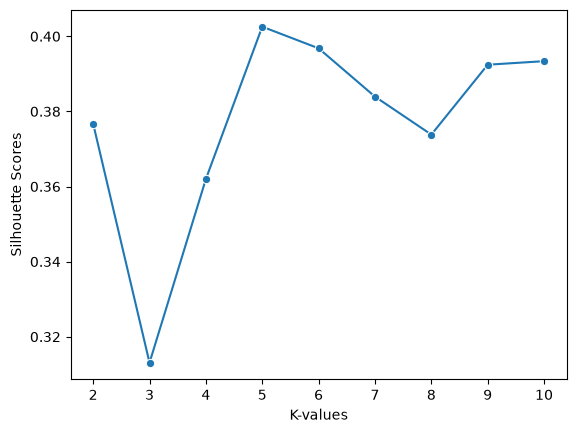

In [32]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    kmeans = KMeans(k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

sns.lineplot(x=range(2,11), y=scores, marker='o')
plt.xlabel("K-values")
plt.ylabel("Silhouette Scores")

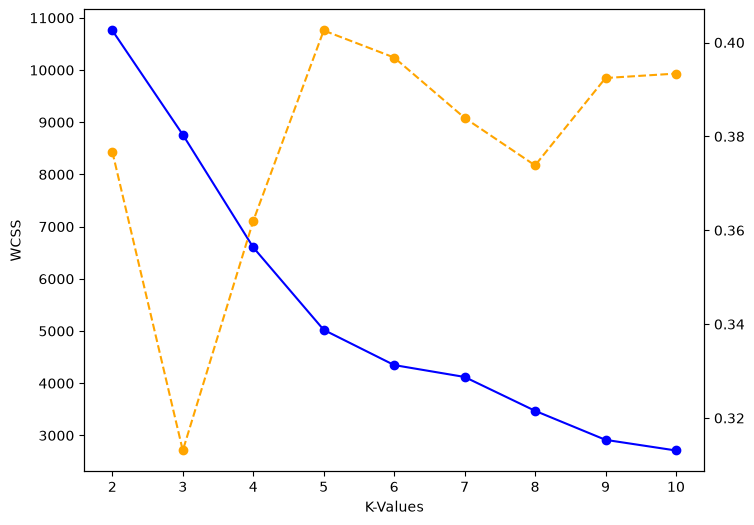

In [33]:
# Combined Plot
k_range = range(2,11)

fig, ax1 = plt.subplots(figsize = (8,6))

ax1.plot(k_range, wcss[1:], marker='o', color='blue')
ax1.set_xlabel("K-Values")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores, marker='o', color='orange', linestyle='--')

# The point where the graph crosses is the optimal K value

In [34]:
wcss

[18269.303437988776,
 10758.052328942762,
 8761.870025531474,
 6602.087298343702,
 5022.502252754808,
 4347.795782138743,
 4119.921920581303,
 3471.22227511121,
 2915.1531741425574,
 2711.0219555935273]

### Clustering

##### 1. K-Means

In [35]:
kmeans = KMeans(4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

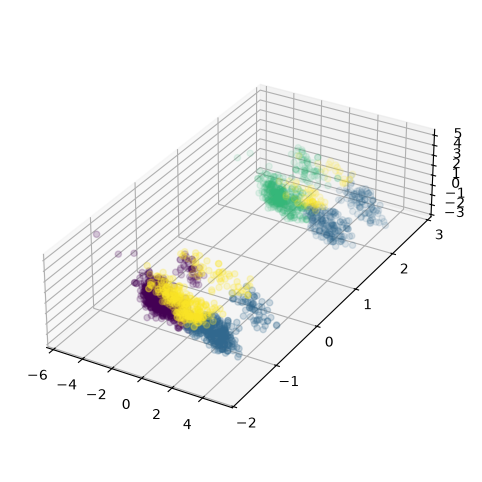

In [36]:
# Plot
fig = plt.figure(figsize=(20,6), dpi=100)
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], alpha=0.5, c=labels_kmeans)
ax.set_box_aspect((2, 4, 1))

##### 2. Agglomerative Clustering

In [37]:
from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering(4, linkage='ward')
labels_agg = agg_clf.fit_predict(X_pca)

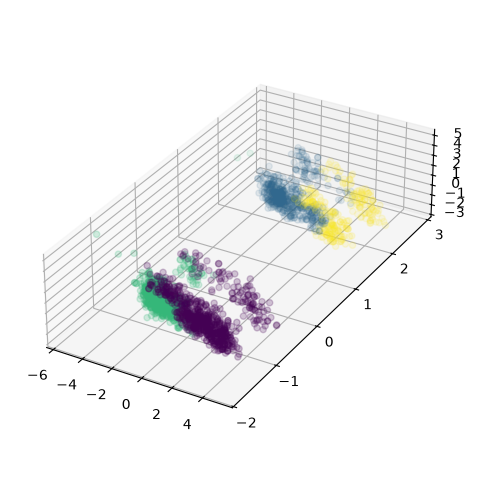

In [38]:
# Plot
fig = plt.figure(figsize=(20,6), dpi=100)
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], alpha=0.5, c=labels_agg)
ax.set_box_aspect((2, 4, 1))

### Characterization of Clusters

In [39]:
df_encoded['Clusters'] = labels_agg

df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Period,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,Clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,1
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,2
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='Clusters', ylabel='count'>

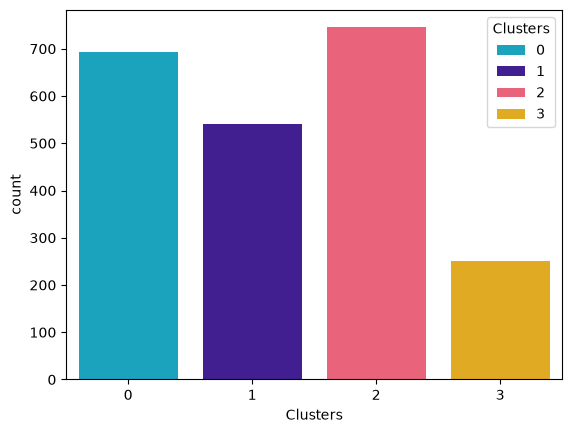

In [40]:
# Cluster Strength
pal = ['#00B4D8', '#3A0CA3', '#FF4D6D', '#FFB703']

sns.countplot(x=df_encoded['Clusters'], palette=pal, hue=df_encoded['Clusters'])

<Axes: xlabel='Total_Spending', ylabel='Income'>

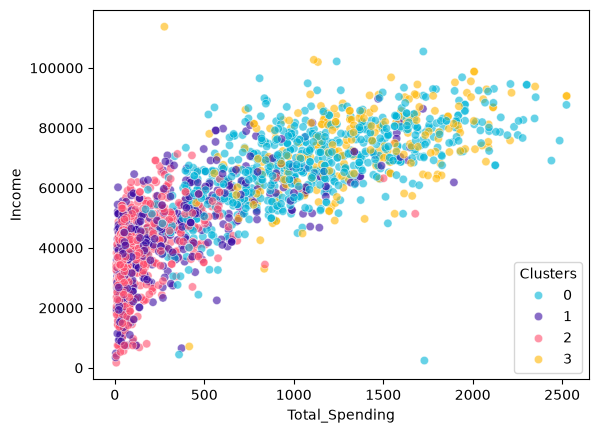

In [41]:
# Income vs Spending pattern

sns.scatterplot(x=df_encoded['Total_Spending'], y=df_encoded['Income'], hue=df_encoded['Clusters'], palette=pal, alpha=0.6)

<span style="display: inline-block; width: 12px; height: 12px; background-color: #00B4D8; border: 1px solid #000; border-radius: 50%; margin-bottom: -1px;"></span> &emsp; **0** $\rightarrow$ Moderate/High Income, High Spending

<span style="display: inline-block; width: 12px; height: 12px; background-color: #3A0CA3; border: 1px solid #000; border-radius: 50%; margin-bottom: -1px;"></span> &emsp; **1** $\rightarrow$ Low/Moderate Income, Low/Moderate Spending

<span style="display: inline-block; width: 12px; height: 12px; background-color: #FF4D6D; border: 1px solid #000; border-radius: 50%; margin-bottom: -1px;"></span> &emsp; **2** $\rightarrow$ Low Income, Low Spending

<span style="display: inline-block; width: 12px; height: 12px; background-color: #FFB703; border: 1px solid #000; border-radius: 50%; margin-bottom: -1px;"></span> &emsp; **3** $\rightarrow$ High Income, High Spending

##### Cluster Summary

In [42]:
cluster_summary = df_encoded.groupby('Clusters').mean()

cluster_summary

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Period,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
Clusters,,,,,,,,,,,,,,,,,,
0,67640.033911,48.406926,2.539683,5.854257,4.668110,8.269841,4.199134,0.007215,0.160173,59.776335,373.816739,1084.246753,0.705628,0.453102,0.477633,0.069264,0.000000,1.000000
1,42210.228704,47.479630,2.507407,3.359259,1.357407,4.500000,6.205556,0.009259,0.135185,56.316667,348.370370,301.733333,1.192593,0.546296,0.327778,0.125926,1.000000,0.000000
2,36228.334899,49.679195,2.214765,2.461745,0.672483,3.544966,6.449664,0.010738,0.063087,54.624161,332.595973,140.908725,1.221477,0.543624,0.289933,0.166443,0.002685,0.997315
3,73313.539841,52.836653,1.621514,5.713147,5.609562,8.581673,3.282869,0.007968,0.410359,58.844622,372.952191,1316.553785,0.314741,0.438247,0.501992,0.059761,1.000000,0.000000


### Customer Profiling

<table border="1">
  <tr>
    <td style="background-color: rgba(0, 180, 216, 0.5);"><div style="text-align: center;"><b><u>C0</u></b></div>
    - moderate/high income <br>
    - fewer children <br>
    - slightly &uparrow; age <br>
    - best response <br>
    - alone <br>
    - web visits &downarrow; <br>
    - store, cat, web purchase &uparrow;
    </td>
    <td style="background-color: rgba(57, 12, 163, 0.5);"><div style="text-align: center;"><b><u>C1</u></b></div>
    - low/moderate income <br>
    - more children <br>
    - poor response <br>
    - partnered <br>
    - webvisits &uparrow; <br>
    - store, cat, web purchase &downarrow; <br>
    &#8203;
    </td>
  </tr>

  <tr>
    <td style="background-color: rgba(255, 77, 110, 0.5);"><div style="text-align: center;"><b><u>C2</u></b></div>
    - low income <br>
    - more children <br>
    - avg response <br>
    - alone <br>
    - web visits &uparrow; <br>
    - store, cat, web purchase &downarrow;&downarrow;&downarrow; <br>
    &#8203;
    </td>
    <td style="background-color: rgba(255, 184, 3, 0.5);"><div style="text-align: center;"><b><u>C3</b></u></div>
    - high income <br>
    - fewer children <br>
    - slightly &uparrow; age <br>
    - avg response <br>
    - partnered <br>
    - web visits &downarrow; <br>
    - store, cat, web purchase &uparrow;
    </td>
  </tr>
</table>

**C0** $\rightarrow$ Premium Customers (Best ROI, Premium Services and Customer Care)

**C1** $\rightarrow$ Family Shoppers (Provide Discounts and Coupons)

**C2** $\rightarrow$ Budget Browsers (Heavy Discounts and Incentive)

**C3** $\rightarrow$ Profitable Customers (Provide Loyalty Programs)